Analyse des données

IMPORTATION

In [ ]:
import torch
import json
import os
import matplotlib.pyplot as plt
from PIL import Image
from deep_translator import GoogleTranslator # <-- NOUVEL IMPORT

uv run --no-sync test.py /mnt/data/users/elise/stage/stage_msiglip/epoch=52-val_score=50.88.ckpt VN3K_VI

analyse t2i et i2t : 

Chargement des données...
📊 Taille totale du JSON : 6302
🎯 Taille du Test Set filtré : 2226
Données chargées avec succès ! Lancement de l'inspection...

=== Test de Recherche T2I ===


/tmp/ipykernel_994562/2182068212.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  rankings_data = torch.load(RANKINGS_FILE)
/tmp/ipykernel_994562/2182068212.py:16: Futur

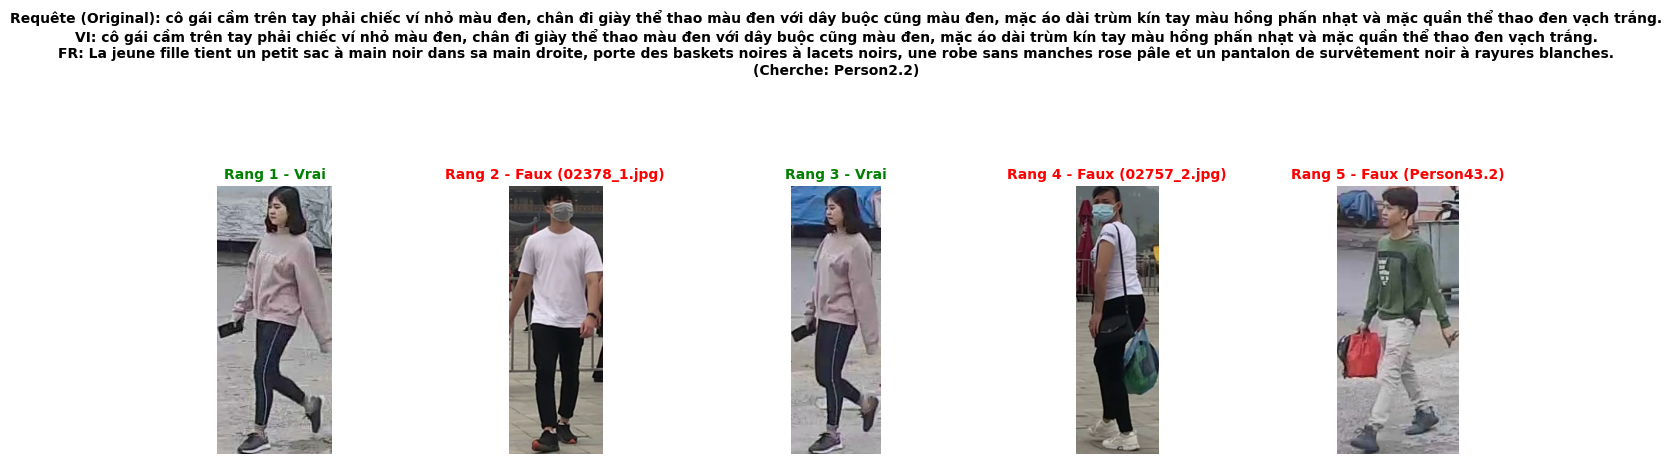

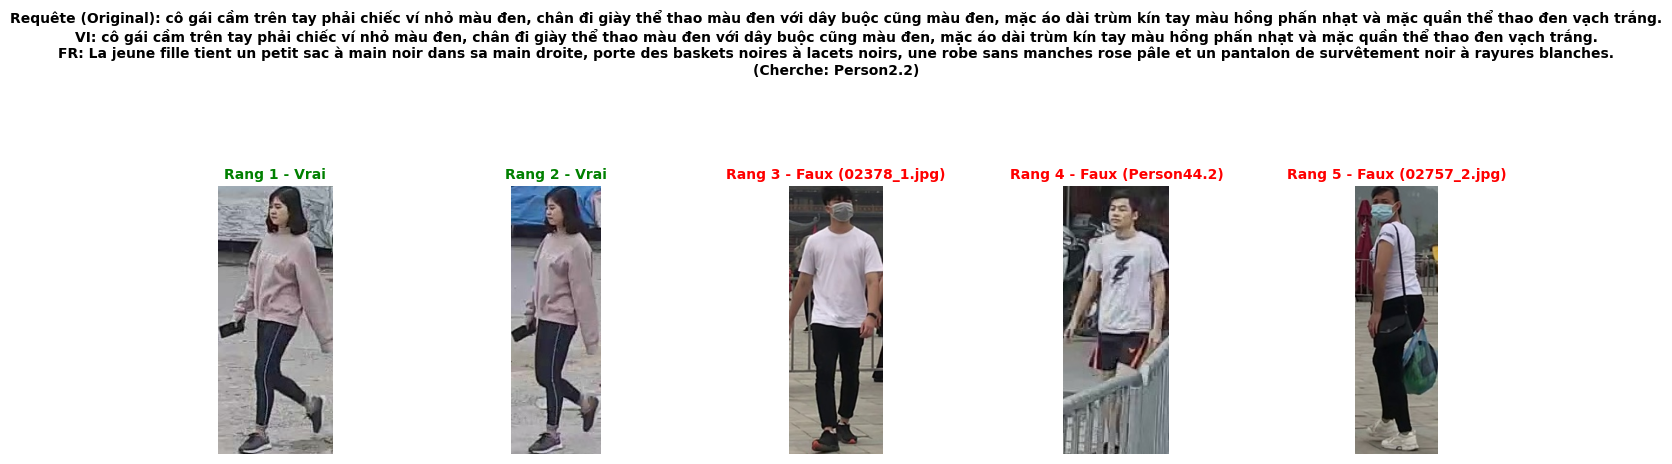


=== Test de Recherche I2T ===


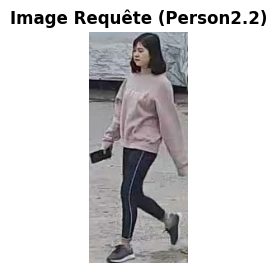


--- TOP 5 DES TEXTES TROUVÉS ---
1. ✅ [Person2.2] : Một cô gái tóc ngắn ngang vai, tay cầm ví màu đen, mặc áo màu hồng nhạt, quần màu đen có sọc trắng, đi giày thể thao.
      VI: Một cô gái tóc ngắn ngang vai, tay cầm ví màu đen, mặc áo màu hồng nhạt, quần màu đen có sọc trắng, đi giày thể thao.
      FR: Une fille aux cheveux mi-longs, tenant un sac à main noir, portant une chemise rose clair, un pantalon noir à rayures blanches et des baskets.

2. ❌ [02012_2.jpg] : nữ mặc áo màu nâu có hoa văn, mặc quần màu đen, đi giày màu đen viền trắng, đội mũ rộng vành màu đen, đeo khẩu trang màu xanh dương, tay trái đang cắp một túi da đen.
      VI: nữ mặc áo màu nâu có hoa văn, mặc quần màu đen, đi giày màu đen viền trắng, đội mũ rộng vành màu đen, đeo khẩu trang màu xanh dương, tay trái đang cắp một túi da đen.
      FR: La femme porte une chemise marron à motifs, un pantalon noir, des chaussures noires avec des bordures blanches, un chapeau noir à larges bords, un masque bleu et porte un s

In [ ]:


# ==========================================
# 1. CONFIGURATION
# ==========================================
BASE_IMG_DIR = "VN3K/imgs/"
RANKINGS_FILE = "mes_rankings_withcir_2.pt" 
RANKINGS_FILE_2 = "mes_rankings_nocir.pt" 
JSON_FILE = "VN3K/data_captions_vn3k.json" 

print("Chargement des données...")

# ---------------------------------------------------------
# /!\ À DÉCOMMENTER 
rankings_data = torch.load(RANKINGS_FILE)
t2i_ranking = rankings_data["t2i"]
i2t_ranking = rankings_data["i2t"]
rankings_data_2 = torch.load(RANKINGS_FILE_2)
t2i_ranking_2 = rankings_data_2["t2i"]
i2t_ranking_2 = rankings_data_2["i2t"]
# ---------------------------------------------------------

with open(JSON_FILE, "r", encoding="utf-8") as f:
    dataset_liste_complet = json.load(f)

dataset_liste = []
for item in dataset_liste_complet:
    is_test = item.get("split") == "test" or item.get("split") == "val" or "test" in item["file_path"].lower()
    if is_test:
        dataset_liste.append(item)

print(f"📊 Taille totale du JSON : {len(dataset_liste_complet)}")
print(f"🎯 Taille du Test Set filtré : {len(dataset_liste)}")

dataset_info = {item["id"]: item for item in dataset_liste}

def get_person_id(file_path):
    return file_path.split('/')[1]

# --- NOUVELLE FONCTION DE TRADUCTION À LA VOLÉE ---
def traduire_pour_affichage(texte):
    """Traduit un texte en vietnamien et en français en ignorant les erreurs de connexion."""
    try:
        txt_vi = GoogleTranslator(source='auto', target='vi').translate(texte)
        txt_fr = GoogleTranslator(source='auto', target='fr').translate(texte)
        return txt_vi, txt_fr
    except Exception as e:
        print(f"[Avertissement] Impossible de traduire à cause d'une erreur réseau.")
        return "Erreur Traduction", "Erreur Traduction"

# ==========================================
# 2. FONCTION T2I (Texte vers Image)
# ==========================================
def inspecter_requete_t2i(index_test_texte, matrice_ranking, dataset_liste, top_k=5):
    index_image_source = index_test_texte // 2 
    index_phrase = index_test_texte % 2
    
    vrai_item = dataset_liste[index_image_source]
    texte_requete = vrai_item["captions"][index_phrase] 
    vraie_personne_id = get_person_id(vrai_item["file_path"])
    
    # TRADUCTION DE LA REQUÊTE
    txt_vi, txt_fr = traduire_pour_affichage(texte_requete)
    
    images_predites_indices = matrice_ranking[index_test_texte][:top_k]
    
    fig, axes = plt.subplots(1, top_k, figsize=(15, 4))
    
    # On met à jour le titre pour inclure les 3 langues
    titre_complet = (f"Requête (Original): {texte_requete}\n"
                     f"VI: {txt_vi}\n"
                     f"FR: {txt_fr}\n"
                     f"(Cherche: {vraie_personne_id})")
    
    # On ajuste un peu la taille de police et la position pour que ça rentre bien
    fig.suptitle(titre_complet, fontsize=10, fontweight="bold", y=1.15)
    
    for i, img_index_tensor in enumerate(images_predites_indices):
        index_image = img_index_tensor.item()
        item_predit = dataset_liste[index_image]
        
        chemin_complet = os.path.join(BASE_IMG_DIR, item_predit["file_path"])
        personne_predite_id = get_person_id(item_predit["file_path"])
        
        ax = axes[i]
        try:
            img = Image.open(chemin_complet)
            ax.imshow(img)
            
            est_correct = (personne_predite_id == vraie_personne_id)
            couleur = "green" if est_correct else "red"
            titre = "Vrai" if est_correct else f"Faux ({personne_predite_id})"
            
            ax.set_title(f"Rang {i+1} - {titre}", color=couleur, fontweight="bold", fontsize=10)
        except FileNotFoundError:
            ax.set_title("Image introuvable")
            
        ax.axis("off")
        
    plt.tight_layout()
    plt.show()

# ==========================================
# 3. FONCTION I2T (Image vers Texte)
# ==========================================
def inspecter_requete_i2t(index_test_image, matrice_ranking, dataset_liste, top_k=5):
    vrai_item = dataset_liste[index_test_image]
    chemin_complet = os.path.join(BASE_IMG_DIR, vrai_item["file_path"])
    vraie_personne_id = get_person_id(vrai_item["file_path"])
    
    try:
        img = Image.open(chemin_complet)
        plt.figure(figsize=(3, 3))
        plt.imshow(img)
        plt.title(f"Image Requête ({vraie_personne_id})", fontweight="bold")
        plt.axis("off")
        plt.show()
    except FileNotFoundError:
        print("Image requête introuvable.")
        return

    textes_predits_indices = matrice_ranking[index_test_image][:top_k]
    print(f"\n--- TOP {top_k} DES TEXTES TROUVÉS ---")
    
    for i, txt_index_tensor in enumerate(textes_predits_indices):
        index_texte = txt_index_tensor.item()
        
        index_image_predite = index_texte // 2
        index_phrase_predite = index_texte % 2
        
        item_predit = dataset_liste[index_image_predite]
        texte_predit = item_predit["captions"][index_phrase_predite]
        
        personne_predite_id = get_person_id(item_predit["file_path"])
        
        # TRADUCTION DU RÉSULTAT
        txt_vi, txt_fr = traduire_pour_affichage(texte_predit)
        
        est_correct = (personne_predite_id == vraie_personne_id)
        symbole = "✅" if est_correct else "❌"
        
        # Affichage structuré dans le terminal
        print(f"{i+1}. {symbole} [{personne_predite_id}] : {texte_predit}")
        print(f"      VI: {txt_vi}")
        print(f"      FR: {txt_fr}\n")

# ==========================================
# 4. EXÉCUTION
# ==========================================
print("Données chargées avec succès ! Lancement de l'inspection...")

index_test = 9

print(f"\n=== Test de Recherche T2I ===")
inspecter_requete_t2i(index_test, t2i_ranking, dataset_liste, top_k=5)
inspecter_requete_t2i(index_test, t2i_ranking_2, dataset_liste, top_k=5)

print(f"\n=== Test de Recherche I2T ===")
inspecter_requete_i2t(index_test // 2, i2t_ranking, dataset_liste, top_k=5)

Visualisation de la circle loss

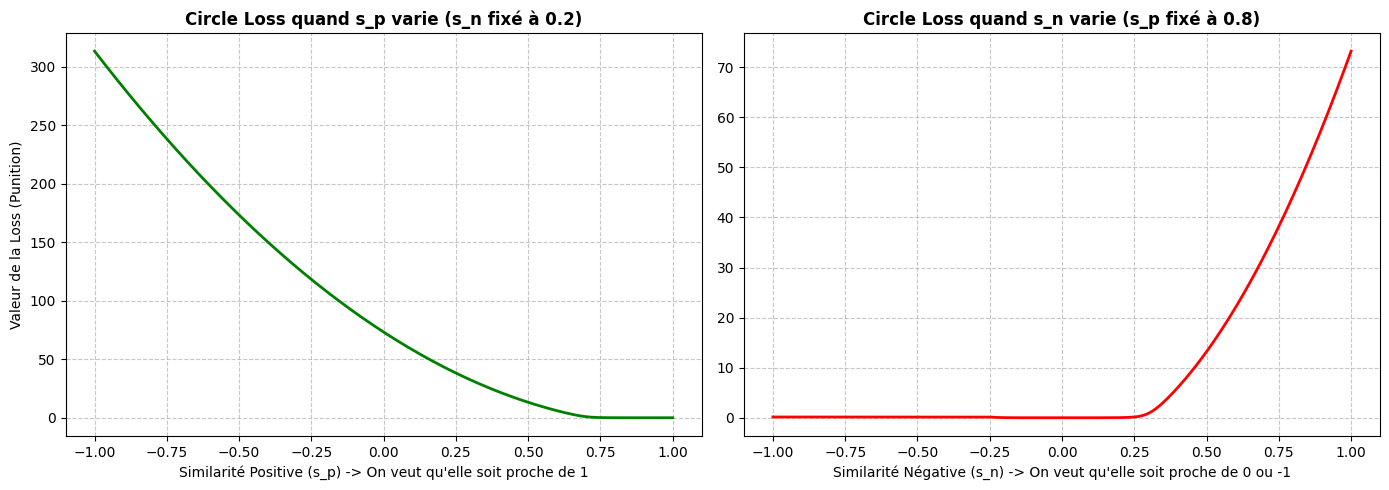

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# On recrée les maths de ta fonction de manière simplifiée pour un seul cas (1 positif, 1 négatif)
def simulated_circle_loss(s_p, s_n, m=0.25, gamma=80):
    # Les poids dynamiques (alpha)
    alpha_p = np.maximum(0, 1 + m - s_p)
    alpha_n = np.maximum(0, s_n + m)
    
    # Les marges (delta)
    delta_p = 1 - m
    delta_n = m
    
    # Les logits
    logit_p = -gamma * alpha_p * (s_p - delta_p)
    logit_n = gamma * alpha_n * (s_n - delta_n)
    
    # Calcul de la loss (simplifié avec log1p pour éviter les erreurs mathématiques extrêmes)
    # L = log(1 + exp(logit_p) * exp(logit_n))
    loss = np.log1p(np.exp(logit_p + logit_n))
    return loss

# --- SCÉNARIO 1 : Évolution de la Loss selon la similarité POSITIVE (s_p) ---
# On fixe le s_n (le négatif) à une valeur moyenne (ex: 0.2)
fixed_sn = 0.2
sp_values = np.linspace(-1, 1, 200) # 200 valeurs entre -1 et 1
loss_sp = [simulated_circle_loss(sp, fixed_sn) for sp in sp_values]

# --- SCÉNARIO 2 : Évolution de la Loss selon la similarité NÉGATIVE (s_n) ---
# On fixe le s_p (le positif) à une bonne valeur (ex: 0.8)
fixed_sp = 0.8
sn_values = np.linspace(-1, 1, 200)
loss_sn = [simulated_circle_loss(fixed_sp, sn) for sn in sn_values]

# --- AFFICHAGE GRAPHIQUE ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Graphe 1
ax1.plot(sp_values, loss_sp, color='green', linewidth=2)
ax1.set_title(f"Circle Loss quand s_p varie (s_n fixé à {fixed_sn})", fontweight="bold")
ax1.set_xlabel("Similarité Positive (s_p) -> On veut qu'elle soit proche de 1")
ax1.set_ylabel("Valeur de la Loss (Punition)")
ax1.grid(True, linestyle='--', alpha=0.7)

# Graphe 2
ax2.plot(sn_values, loss_sn, color='red', linewidth=2)
ax2.set_title(f"Circle Loss quand s_n varie (s_p fixé à {fixed_sp})", fontweight="bold")
ax2.set_xlabel("Similarité Négative (s_n) -> On veut qu'elle soit proche de 0 ou -1")
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

ANALYSE DU DATASET

--- RÉSULTATS DE L'ANALYSE ---
Nombre total d'identités uniques : 3000
Moyenne d'images par personne : 2.1
Maximum d'images pour une seule personne : 8
Minimum d'images pour une seule personne : 2
Longueur moyenne des textes : 28.9 mots


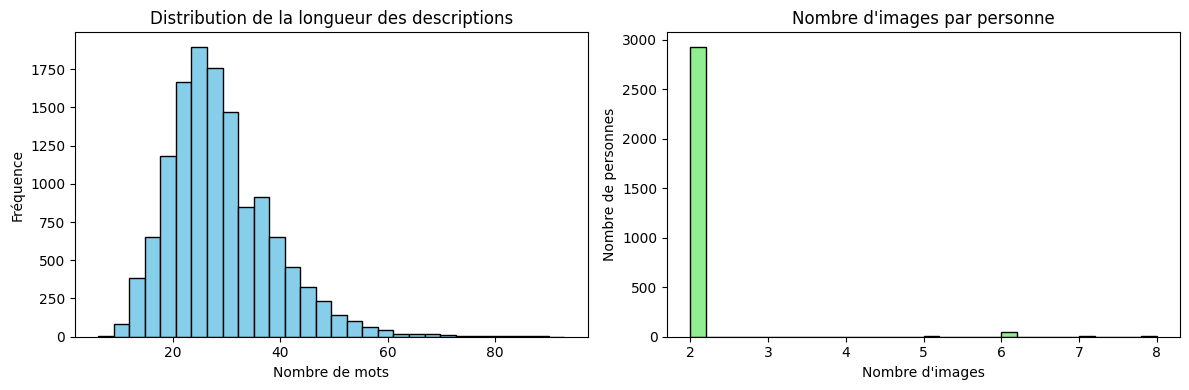

In [1]:
import json
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np

# 1. Charger le fichier JSON
JSON_FILE = "../mSigLIP-CLoRA/VN3K/data_captions_vn3k.json"

with open(JSON_FILE, "r", encoding="utf-8") as f:
    data = json.load(f)

# Si ton JSON est une liste, on l'utilise directement. Si c'est un dico, adapte la clé.
# data = data["images"] # (Décommente si nécessaire)

text_lengths = []
person_identities = []

# 2. Extraire les données
for item in data:
    # Récupérer l'ID de la personne
    person_identities.append(item.get('id', 'inconnu'))
    
    # Récupérer les descriptions (parfois c'est une liste, parfois un texte simple)
    captions = item.get('captions', [])
    if isinstance(captions, str):
        captions = [captions]
        
    for cap in captions:
        # Compter le nombre de mots (en séparant par les espaces)
        text_lengths.append(len(cap.split()))

# 3. Calculer les statistiques
id_counts = Counter(person_identities)
images_per_person = list(id_counts.values())

print(f"--- RÉSULTATS DE L'ANALYSE ---")
print(f"Nombre total d'identités uniques : {len(id_counts)}")
print(f"Moyenne d'images par personne : {np.mean(images_per_person):.1f}")
print(f"Maximum d'images pour une seule personne : {np.max(images_per_person)}")
print(f"Minimum d'images pour une seule personne : {np.min(images_per_person)}")
print(f"Longueur moyenne des textes : {np.mean(text_lengths):.1f} mots")

# 4. Affichage des graphiques
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Graphique de gauche : Longueur des textes
ax1.hist(text_lengths, bins=30, color='skyblue', edgecolor='black')
ax1.set_title("Distribution de la longueur des descriptions")
ax1.set_xlabel("Nombre de mots")
ax1.set_ylabel("Fréquence")

# Graphique de droite : Images par personne
ax2.hist(images_per_person, bins=30, color='lightgreen', edgecolor='black')
ax2.set_title("Nombre d'images par personne")
ax2.set_xlabel("Nombre d'images")
ax2.set_ylabel("Nombre de personnes")

plt.tight_layout()
plt.show()

In [7]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as T

# 1. Chemin vers le dossier des images
BASE_IMG_DIR = "../mSigLIP-CLoRA/VN3K/imgs/TRAINING_DATA"

# Prendre une image au hasard dans le dossier
all_images = [f for f in os.listdir(BASE_IMG_DIR) if f.endswith(('.jpg', '.png', '.jpeg'))]
random_img_name = random.choice(all_images)
img_path = os.path.join(BASE_IMG_DIR, random_img_name)

# Charger l'image originale
original_img = Image.open(img_path).convert('RGB')

# 2. Définir les transformations (similaires à ton entraînement)
# On simule ce que PyTorch fait à tes images en coulisses
augmentations = T.Compose([
    T.Resize((224, 224)), # Taille standard pour SigLIP
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    T.RandomHorizontalFlip(p=1.0), # On force le retournement pour l'exemple
    # T.RandomErasing() s'applique sur des Tenseurs, on le simule mentalement ici
])

# 3. Créer plusieurs versions augmentées
fig, axes = plt.subplots(1, 4, figsize=(15, 5))

# Afficher l'originale
axes[0].imshow(original_img)
axes[0].set_title("Originale")
axes[0].axis('off')

# Afficher 3 variations
for i in range(1, 4):
    aug_img = augmentations(original_img)
    axes[i].imshow(aug_img)
    axes[i].set_title(f"Augmentation {i}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

RuntimeError: Detected that PyTorch and torchvision were compiled with different CUDA major versions. PyTorch has CUDA Version=13.0 and torchvision has CUDA Version=12.4. Please reinstall the torchvision that matches your PyTorch install.